epoch:0,loss:3338.189697265625
epoch:1,loss:429.509033203125
epoch:2,loss:108.37853240966797
epoch:3,loss:72.92437744140625
epoch:4,loss:69.01008605957031
epoch:5,loss:68.57792663574219
epoch:6,loss:68.53019714355469
epoch:7,loss:68.52493286132812
epoch:8,loss:68.52435302734375
epoch:9,loss:68.5242691040039
epoch:10,loss:68.5242691040039
epoch:11,loss:68.52426147460938
epoch:12,loss:68.52425384521484
epoch:13,loss:68.52425384521484
epoch:14,loss:68.52425384521484
epoch:15,loss:68.52424621582031
epoch:16,loss:68.52423858642578
epoch:17,loss:68.52423858642578
epoch:18,loss:68.52423095703125
epoch:19,loss:68.52423095703125
epoch:20,loss:68.52423095703125
epoch:21,loss:68.52421569824219
epoch:22,loss:68.52421569824219
epoch:23,loss:68.52420043945312
epoch:24,loss:68.52420043945312
epoch:25,loss:68.52420806884766
epoch:26,loss:68.5241928100586
epoch:27,loss:68.5241928100586
epoch:28,loss:68.5241928100586
epoch:29,loss:68.5241928100586
epoch:30,loss:68.52417755126953
epoch:31,loss:68.5241775

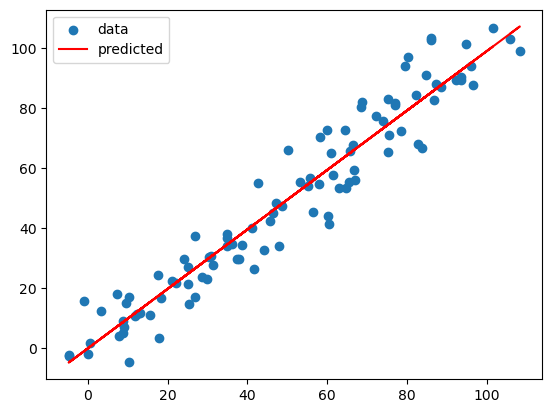

In [9]:
from book_charter.base_tensorflow.tensor import history

'''
    1.导库
    2.定义损失函数
    3.定义预测值函数
    4.定义训练函数
    5.产生随机数作为数据集
    6.训练模型(自动微分)
'''

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

w = tf.Variable(0.0)
b = tf.Variable(0.0)



#损失函数使用均方差
def loss(y_true,y_pred):
    return tf.reduce_mean(tf.square(y_true-y_pred))
#定义预测值函数
def predict(X):
    return w * X + b

#定义训练函数
def train(X,y,epochs = 40,lr = 0.0001):
    current_loss = 0  #损失函数值
    for epoch in range(epochs): #执行训练周期
        with tf.GradientTape() as t: #自动微分
            current_loss = loss(y,predict(X)) #计算损失函数值
        dw,db = t.gradient(current_loss,[w,b]) #取得w,b的梯度

        #更新权重  新权重 = 当前权重-学习率*梯度
        w.assign_sub(lr*dw)
        b.assign_sub(lr*db)

        #打印训练周期和损失函数值
        print(f'epoch:{epoch},loss:{current_loss}')

#产生随机数作为数据集
n = 100
x = np.linspace(0,100,n)
y = np.linspace(0,100,n)

#数据中加入噪声
X = x + np.random.uniform(-10,10,n)
Y = y + np.random.uniform(-10,10,n)

#执行训练
train(X,Y)
#w,b的最优解
print(f'最优解---> w:{w.numpy()},b:{b.numpy()}')


##显示结果
plt.scatter(X,Y,label='data')
plt.plot(X,predict(X),'r',label='predicted')
plt.legend()



E:\develop\anaconda3\envs\d2l_tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


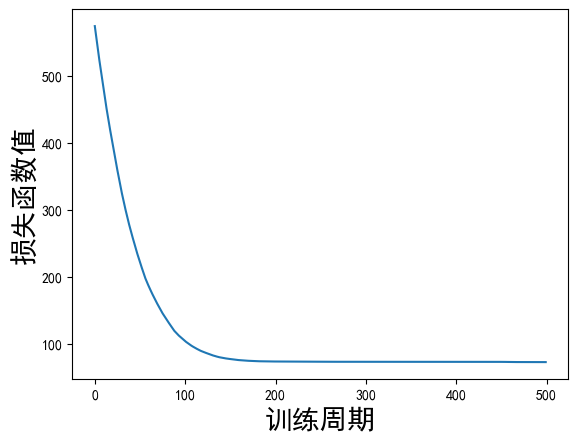

In [10]:
'''
    使用神经网络层实现上面的案例
'''
import tensorflow as tf
import numpy as np

#产生随机数
n = 100
x = np.linspace(0,100,n)
y = np.linspace(0,100,n)

#加入噪音
X = x + np.random.uniform(-10,10,n)
Y = y + np.random.uniform(-10,10,n)

#建立模型(仅使用一个神经网络层--->完全连接层)
##定义神经层参数:  input_shape 输入神经元个数 units:输出神经元个数
layer1 = tf.keras.layers.Dense(units=1,input_shape=[1])

##将神经层加入神经网络
model = tf.keras.Sequential([layer1])

#定义模型的损失函数和优化器
model.compile(loss='mean_squared_error',optimizer=tf.keras.optimizers.Adam())

#模型训练
history = model.fit(X,Y,epochs=500,verbose=False)

#可视化结果
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.xlabel('训练周期',fontsize=20)
plt.ylabel('损失函数值',fontsize=20)
plt.plot(history.history['loss'],label='训练损失函数值')